La Min Oo 6540039</br>
Set Kaung Lwin 6632017</br>
Sein Win Htut  6611040</br>

In [ ]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import time
from multiprocessing import Pool
from sk.features import extract_features
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.multioutput import MultiOutputClassifier

import warnings
import parselmouth

warnings.filterwarnings("ignore", category=parselmouth.PraatWarning)

In [20]:
sample_rate = 22050
audio_files_meta = "metadata.csv"
augmented_meta = "metadata_augmented.csv"
in_dir = "audio_files"
out_dir = "audio_files_augmented"

In [21]:
full_df = pd.read_csv("metadata_augmented.csv")
full_df['original_stem'] = full_df['file_name'].apply(lambda x: x.split('__')[0].replace('.wav', ''))

groups = full_df['original_stem'].values

In [22]:
# need for jupyter problems
if __name__ == '__main__':

    file_paths = []
    for _, row in full_df.iterrows():
        fname = row["file_name"]
        if not fname.endswith(".wav"):
            fname += ".wav"
            
        if row["augmentation"] == "original":
            path = os.path.join("audio_files", fname)
        else:
            path = os.path.join("audio_files_augmented", fname)
            
        file_paths.append(path)

    start = time.time()
    results = []
    completed = 0

    with Pool(processes=6) as pool:
        for features in pool.imap(extract_features, file_paths):
            results.append(features)
            completed += 1
            if completed % 120 == 0:
                elapsed = time.time() - start
                print(f"[{completed}/{len(file_paths)}] {elapsed:.1f}s — {elapsed/completed:.2f}s/file")

    X = np.array(results)
    print(f"Done — {time.time()-start:.1f}s total, shape: {X.shape}")

    y_emotion_raw   = np.array(full_df["emotion"].tolist())    
    y_intensity_raw = np.array(full_df["intensity"].tolist())  
    y_gender_raw    = np.array(full_df["gender"].tolist())     

    emotion_encoder = LabelEncoder()
    intensity_encoder = LabelEncoder()
    gender_encoder = LabelEncoder()

    y_emotion = emotion_encoder.fit_transform(y_emotion_raw)
    y_intensity = intensity_encoder.fit_transform(y_intensity_raw)
    y_gender = gender_encoder.fit_transform(y_gender_raw)

    y = np.column_stack([y_emotion, y_intensity, y_gender])

    
    os.makedirs("models", exist_ok=True)
    np.save("models/X_features.npy", X)
    np.save("models/y_labels.npy", y)
    
    print("Features and labels saved successfully.")

[120/3360] 10.9s — 0.09s/file
[240/3360] 20.4s — 0.09s/file
[360/3360] 29.5s — 0.08s/file
[480/3360] 38.2s — 0.08s/file
[600/3360] 47.9s — 0.08s/file
[720/3360] 53.9s — 0.07s/file
[840/3360] 56.1s — 0.07s/file
[960/3360] 58.2s — 0.06s/file
[1080/3360] 61.1s — 0.06s/file
[1200/3360] 63.7s — 0.05s/file
[1320/3360] 65.8s — 0.05s/file
[1440/3360] 68.0s — 0.05s/file
[1560/3360] 70.1s — 0.04s/file
[1680/3360] 72.0s — 0.04s/file
[1800/3360] 74.1s — 0.04s/file
[1920/3360] 76.0s — 0.04s/file
[2040/3360] 78.3s — 0.04s/file
[2160/3360] 80.7s — 0.04s/file
[2280/3360] 83.0s — 0.04s/file
[2400/3360] 85.3s — 0.04s/file
[2520/3360] 87.6s — 0.03s/file
[2640/3360] 89.7s — 0.03s/file
[2760/3360] 91.9s — 0.03s/file
[2880/3360] 94.3s — 0.03s/file
[3000/3360] 96.6s — 0.03s/file
[3120/3360] 99.3s — 0.03s/file
[3240/3360] 101.7s — 0.03s/file
[3360/3360] 104.3s — 0.03s/file
Done — 104.3s total, shape: (3360, 26)
Features and labels saved successfully.


In [23]:
joblib.dump(emotion_encoder, os.path.join("models", "svm_emotion_encoder_improv.pkl"))
joblib.dump(intensity_encoder, os.path.join("models", "svm_intensity_encoder_improv.pkl"))
joblib.dump(gender_encoder, os.path.join("models", "svm_gender_encoder_improv.pkl"))

['models/svm_gender_encoder_improv.pkl']

In [24]:
X = np.load("models/X_features.npy")
y = np.load("models/y_labels.npy")

groups = np.asarray(groups)
if len(groups) != len(X):
    groups = groups[:len(X)]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
gkf = GroupKFold(n_splits=5)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

base_svm = MultiOutputClassifier(
    SVC(class_weight="balanced", probability=True)
 )

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("estimator", base_svm),
])


param_grid = {
    "estimator__estimator__C": [0.1, 1, 10],
    "estimator__estimator__gamma": ["scale", 0.001, 0.01],
    "estimator__estimator__kernel": ["rbf"],
}

multi_svm = GridSearchCV(
    pipe,
    param_grid,
    cv=gkf,
    n_jobs=-1,
    verbose=1,
)

Train size: 2685 | Test size: 675


In [25]:
multi_svm.fit(X_train, y_train, groups=groups_train)
print(f"Best C: {multi_svm.best_params_['estimator__estimator__C']}")
print(f"Best Gamma: {multi_svm.best_params_['estimator__estimator__gamma']}")
print(f"Best Kernel: {multi_svm.best_params_['estimator__estimator__kernel']}")
print(f"Best Cross-Validation Score: {multi_svm.best_score_:.4f}")
joblib.dump(multi_svm, os.path.join("models", "svm_multi_improv.pkl"))

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best C: 10
Best Gamma: 0.01
Best Kernel: rbf
Best Cross-Validation Score: 0.2012


['models/svm_multi_improv.pkl']

In [26]:
emotion_encoder = joblib.load(os.path.join("models","svm_emotion_encoder_improv.pkl"))
intensity_encoder = joblib.load(os.path.join("models","svm_intensity_encoder_improv.pkl"))
gender_encoder = joblib.load(os.path.join("models","svm_gender_encoder_improv.pkl"))

multi_svm = joblib.load(os.path.join("models","svm_multi_improv.pkl"))

Overall Accuracy
Emotion Accuracy:   43.70%
Intensity Accuracy: 68.15%
Gender Accuracy:    83.56%
Emotion
              precision    recall  f1-score   support

       angry       0.49      0.48      0.48       105
        calm       0.70      0.73      0.72       140
     disgust       0.28      0.42      0.33        65
     fearful       0.45      0.36      0.40        70
       happy       0.30      0.26      0.28        95
         sad       0.25      0.16      0.19        90
   surprised       0.38      0.47      0.42       110

    accuracy                           0.44       675
   macro avg       0.41      0.41      0.40       675
weighted avg       0.43      0.44      0.43       675

Intensity
              precision    recall  f1-score   support

      normal       0.60      0.84      0.70       300
      strong       0.81      0.55      0.66       375

    accuracy                           0.68       675
   macro avg       0.71      0.70      0.68       675
weighted avg   

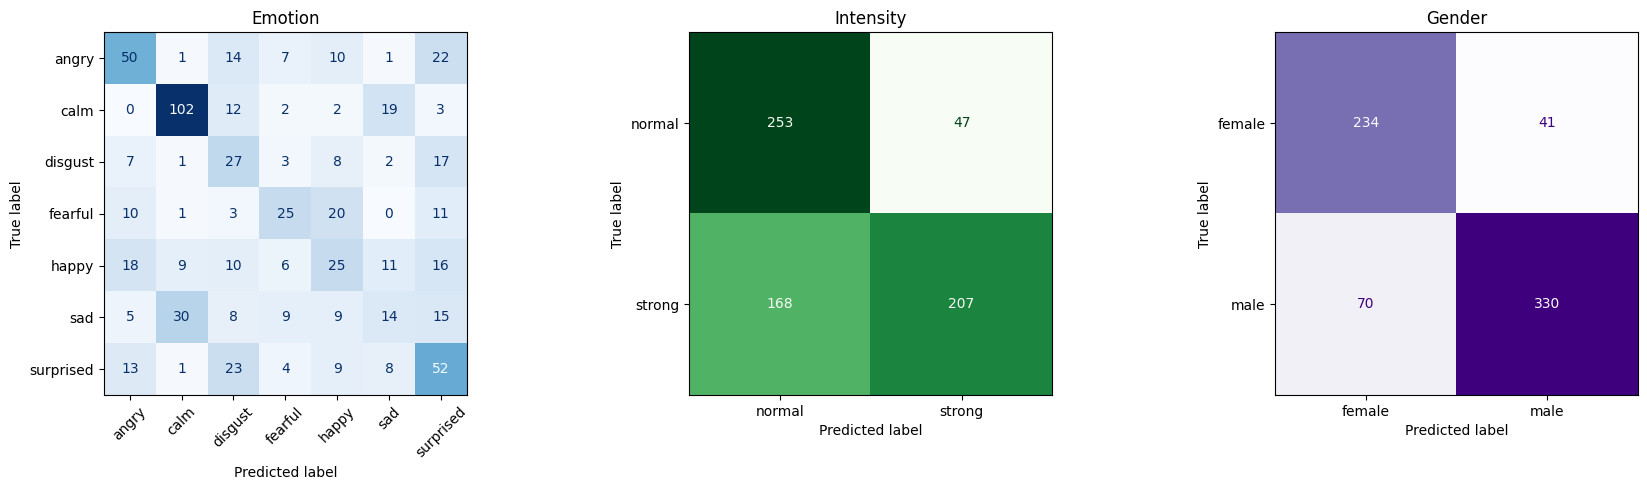

In [27]:
y_pred = multi_svm.predict(X_test)

y_emotion_pred = y_pred[:, 0]
y_intensity_pred = y_pred[:, 1]
y_gender_pred = y_pred[:, 2]

y_emotion_test = y_test[:, 0]
y_intensity_test = y_test[:, 1]
y_gender_test = y_test[:, 2]

emotion_acc = accuracy_score(y_emotion_test, y_emotion_pred )
intensity_acc = accuracy_score(y_intensity_test, y_intensity_pred)
gender_acc = accuracy_score(y_gender_test, y_gender_pred)

print("Overall Accuracy")

print(f"Emotion Accuracy:   {emotion_acc:.2%}")
print(f"Intensity Accuracy: {intensity_acc:.2%}")
print(f"Gender Accuracy:    {gender_acc:.2%}")

print("Emotion")
print(classification_report(y_emotion_test, y_emotion_pred, target_names=emotion_encoder.classes_))

print("Intensity")
print(classification_report(y_intensity_test, y_intensity_pred, target_names=intensity_encoder.classes_))

print("Gender")
print(classification_report(y_gender_test, y_gender_pred, target_names=gender_encoder.classes_))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_emotion = confusion_matrix(y_emotion_test, y_emotion_pred)
ConfusionMatrixDisplay(cm_emotion, display_labels=emotion_encoder.classes_).plot(
    ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=45
)
axes[0].set_title("Emotion")

cm_intensity = confusion_matrix(y_intensity_test, y_intensity_pred)
ConfusionMatrixDisplay(cm_intensity, display_labels=intensity_encoder.classes_).plot(
    ax=axes[1], cmap="Greens", colorbar=False
)
axes[1].set_title("Intensity")

cm_gender = confusion_matrix(y_gender_test, y_gender_pred)
ConfusionMatrixDisplay(cm_gender, display_labels=gender_encoder.classes_).plot(
    ax=axes[2], cmap="Purples", colorbar=False
)
axes[2].set_title("Gender")

plt.tight_layout()
plt.show()